# Accumulated Heat Anomalies and more

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [7]:
# write that out for later use
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2022_LAND_summer_stats.nc'
ds_land = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1961-2022_OCEAN_summer_stats.nc'
ds_ocean = xr.open_dataset(input_path2)

In [8]:
# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_land.lat))
weights.name = "weights"

In [9]:
mean_base_midlat_land_heat = ds_land.sel(time=slice('1961','1990')).SummerHeat.where(((ds_land.lat >= 23.5) & 
                                                                                     (ds_land.lat <= 70)) |
                                                                                     ((ds_land.lat <= -23.5) &
                                                                                       (ds_land.lat >= -70))).mean(dim=['time'])
mean_base_midlat_land_heat

<xarray.DataArray 'SummerHeat' (lat: 721, lon: 1440)> Size: 8MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

In [10]:
mean_midlat_land_heat = ds_land.sel(time=slice('2000','2022')).SummerHeat.where(((ds_land.lat >= 23.5) & 
                                                                                     (ds_land.lat <= 70)) |
                                                                                     ((ds_land.lat <= -23.5) &
                                                                                       (ds_land.lat >= -70))).mean(dim=['time'])
mean_midlat_land_heat

<xarray.DataArray 'SummerHeat' (lat: 721, lon: 1440)> Size: 8MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

In [11]:
midlat_land_heat_anom = mean_midlat_land_heat - mean_base_midlat_land_heat

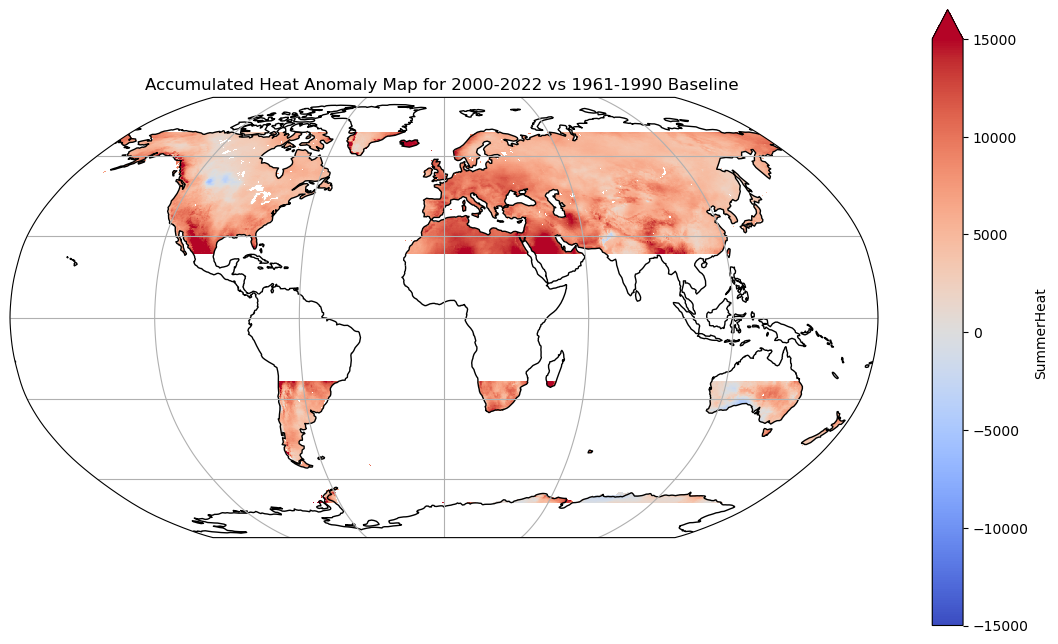

In [29]:


# Summer Heat Anomaly 2000-2022 vs 1961-1990 baseline
fig = plt.figure(figsize=(14,8))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

#ds_full.SummerR2.where(ds_full.SummerR2 > 0.2).plot(
midlat_land_heat_anom.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-15000,
    vmax=15000, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Accumulated Heat Anomaly Map for 2000-2022 vs 1961-1990 Baseline ")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

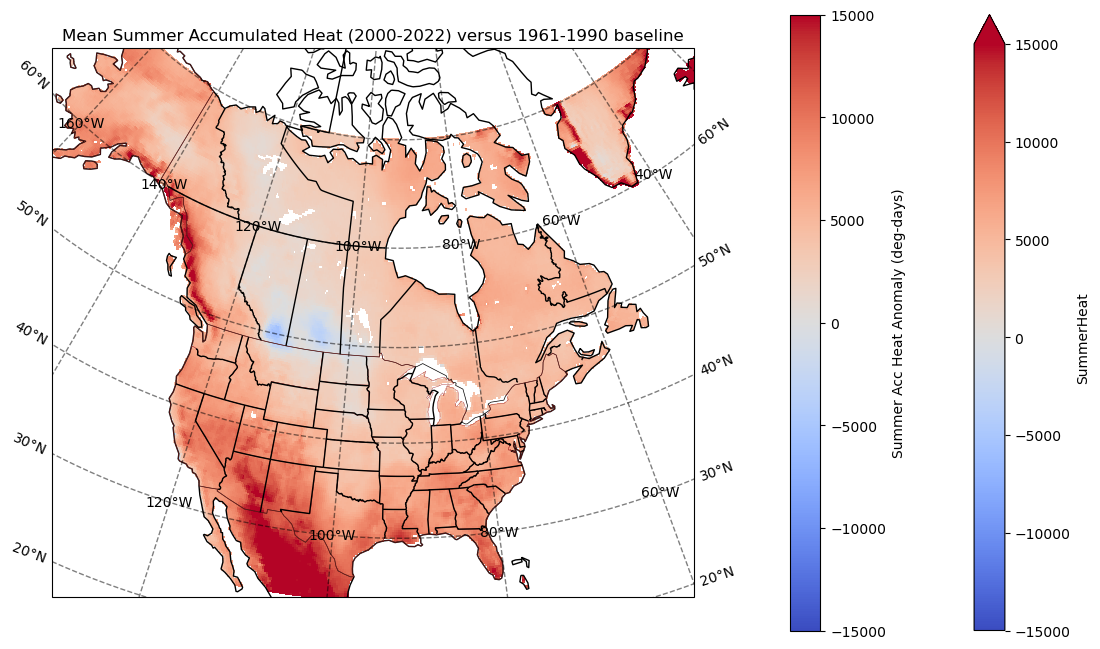

In [28]:

central_longitude = -(91 + 52 / 60)
central_latitude = 40

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(14,8))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = midlat_land_heat_anom.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-15000,
    vmax=15000, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    
)

ax.set_extent((-130, -60, 20, 75))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)


plt.colorbar(dataplot,label="Summer Acc Heat Anomaly (deg-days)", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer Accumulated Heat (2000-2022) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



In [14]:
mean_base_midlat_ocean_heat = ds_ocean.sel(time=slice('1961','1990')).SummerHeat.where(((ds_ocean.lat >= 23.5) & 
                                                                                     (ds_ocean.lat <= 70)) |
                                                                                     ((ds_ocean.lat <= -23.5) &
                                                                                       (ds_ocean.lat >= -70))).mean(dim=['time'])

mean_midlat_ocean_heat = ds_ocean.sel(time=slice('2000','2022')).SummerHeat.where(((ds_ocean.lat >= 23.5) & 
                                                                                     (ds_ocean.lat <= 70)) |
                                                                                     ((ds_ocean.lat <= -23.5) &
                                                                                       (ds_ocean.lat >= -70))).mean(dim=['time'])

midlat_ocean_heat_anom = mean_midlat_ocean_heat - mean_base_midlat_ocean_heat

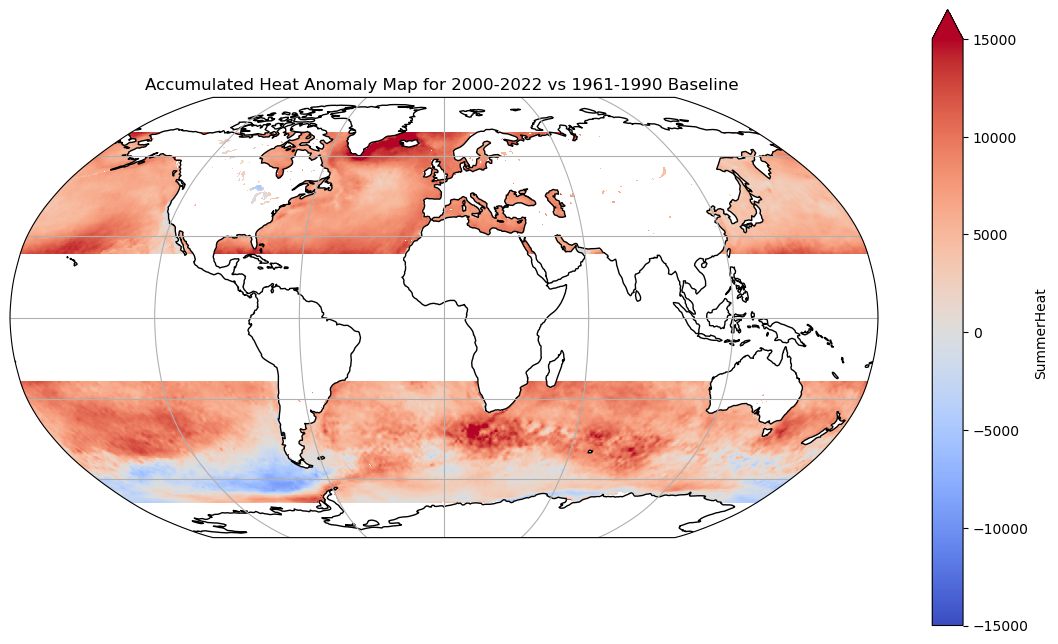

In [30]:


# Summer Heat Anomaly 2000-2022 vs 1961-1990 baseline
fig = plt.figure(figsize=(14,8))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

#ds_full.SummerR2.where(ds_full.SummerR2 > 0.2).plot(
midlat_ocean_heat_anom.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-15000,
    vmax=15000, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Accumulated Heat Anomaly Map for 2000-2022 vs 1961-1990 Baseline ")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

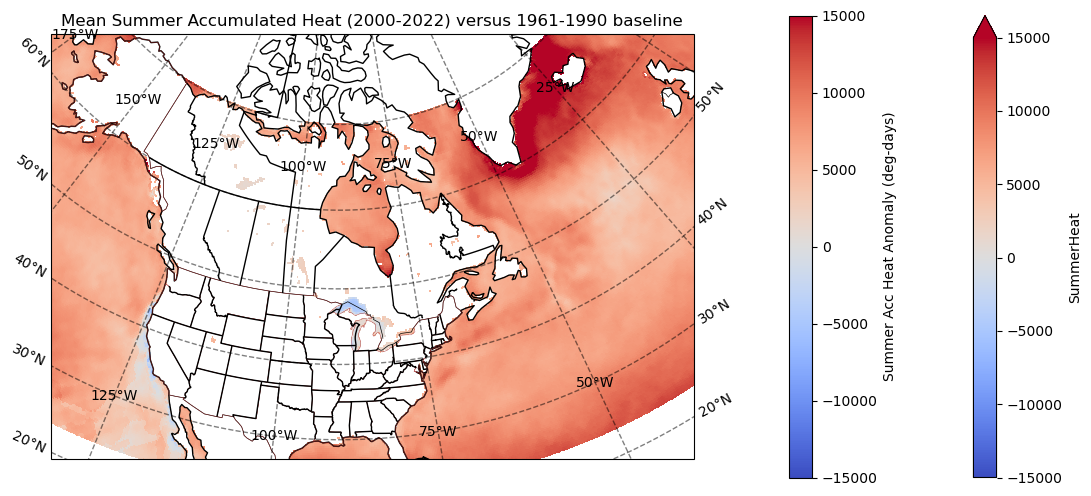

In [37]:

central_longitude = -90#-(91 + 52 / 60)
central_latitude = 60

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(14,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = midlat_ocean_heat_anom.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-15000,
    vmax=15000, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    
)

ax.set_extent((-130, -40, 20, 75))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)


plt.colorbar(dataplot,label="Summer Acc Heat Anomaly (deg-days)", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer Accumulated Heat (2000-2022) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



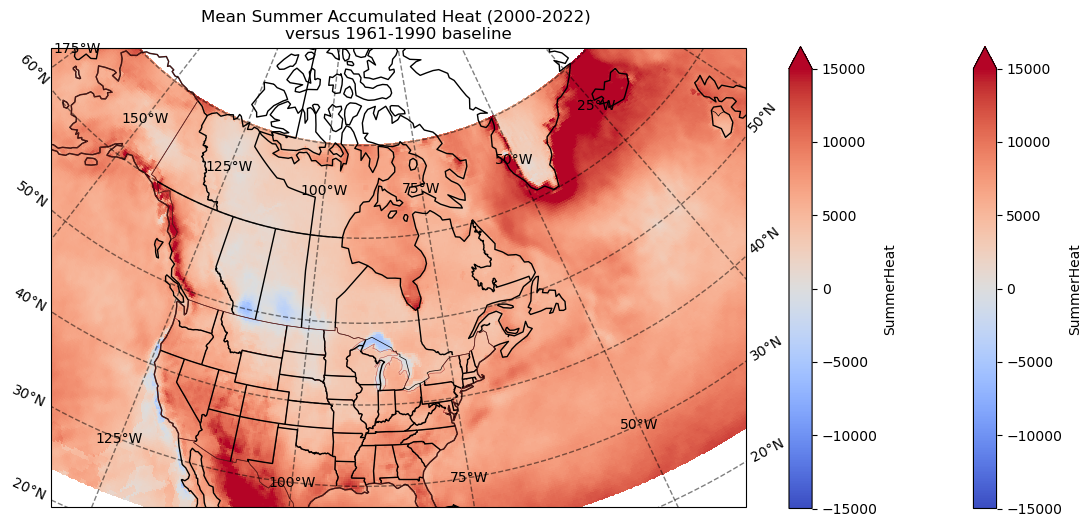

In [60]:
# will this work?


central_longitude = -90#-(91 + 52 / 60)
central_latitude = 60

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(14,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = midlat_ocean_heat_anom.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-15000,
    vmax=15000, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    
)

dataplot2 = midlat_land_heat_anom.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-15000,
    vmax=15000, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
)


ax.set_extent((-130, -40, 20, 75))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)

#fig.colorbar(dataplot).remove()
#plt.colorbar(dataplot2,label="Summer Acc Heat Anomaly (deg-days)", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer Accumulated Heat (2000-2022) \nversus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()

